In [1]:
import os
import logging
import base64
from pathlib import Path
from dotenv import load_dotenv
from openai import OpenAI
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_chroma import Chroma
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

In [2]:
client = OpenAI()   

Download Sample Image

In [3]:
import urllib.request


# Folder to save images
data_dir = Path(r'C:\Users\USER\rag_course\14_multimodal_rag\data')
data_dir.mkdir(parents=True, exist_ok=True)

# Sample crop disease images
samples = {
    'cassava_mosaic.jpg': 'https://upload.wikimedia.org/wikipedia/commons/thumb/5/5e/Cassava_mosaic_disease.jpg/640px-Cassava_mosaic_disease.jpg',
    'maize_smut.jpg':     'https://upload.wikimedia.org/wikipedia/commons/thumb/2/2a/Ustilago_maydis_1.jpg/640px-Ustilago_maydis_1.jpg',
    'rice_blast.jpg':     'https://upload.wikimedia.org/wikipedia/commons/thumb/8/85/Rice_blast_symptoms.jpg/640px-Rice_blast_symptoms.jpg',
    'tomato_leaf_curl.jpg':'https://upload.wikimedia.org/wikipedia/commons/thumb/0/0b/Tomato_leaf_curl_virus.jpg/640px-Tomato_leaf_curl_virus.jpg',
}

# Download each image
for name, url in samples.items():
    path = data_dir / name
    if path.exists():
        print(f'Already exists: {name}')
        continue
    try:
        urllib.request.urlretrieve(url, path)
        print(f'Downloaded: {name} ({path.stat().st_size / 1024:.1f} KB)')
    except Exception as e:
        print(f'Failed: {name} — {e}')

Failed: cassava_mosaic.jpg — HTTP Error 403: Forbidden
Failed: maize_smut.jpg — HTTP Error 403: Forbidden
Failed: rice_blast.jpg — HTTP Error 403: Forbidden
Failed: tomato_leaf_curl.jpg — HTTP Error 403: Forbidden


In [4]:
from pathlib import Path

# Folder where you placed your images
data_dir = Path(r'C:\Users\USER\rag_course\14_multimodal_rag\data')

# List all images in the folder
image_files = sorted([
    f for f in data_dir.iterdir()
    if f.suffix.lower() in {'.jpg', '.jpeg', '.png'}
])

print(f'✅ Found {len(image_files)} image(s):')
for f in image_files:
    print(f'   {f.name} ({f.stat().st_size / 1024:.1f} KB)')

✅ Found 10 image(s):
   0a79700b-f834-41f5-ae51-6ceda6f67a48___RS_Early.B 8951.JPG (22.0 KB)
   0ad3ba53-f01b-403b-a99d-5991eed85045___RS_Early.B 7600.JPG (15.4 KB)
   0bbb8bce-2020-416b-8bd6-c160c2db9921___RS_Early.B 8386.JPG (20.7 KB)
   0c4f6f72-c7a2-42e1-9671-41ab3bf37fe7___RS_Early.B 6752.JPG (22.0 KB)
   0c5b14d9-8b1c-4c39-bb23-1835b5760caa___RS_Early.B 7937.JPG (19.8 KB)
   0d2e2971-f1c9-4278-b35c-91dd8a22a64d___RS_Early.B 7581.JPG (19.2 KB)
   RS_Rust 1565.JPG (14.7 KB)
   RS_Rust 1566.JPG (15.8 KB)
   RS_Rust 1568_flipLR.JPG (12.2 KB)
   RS_Rust 1569.JPG (15.2 KB)


--- 0a79700b-f834-41f5-ae51-6ceda6f67a48___RS_Early.B 8951.JPG ---


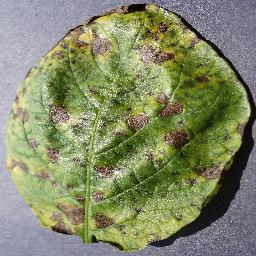


--- 0ad3ba53-f01b-403b-a99d-5991eed85045___RS_Early.B 7600.JPG ---


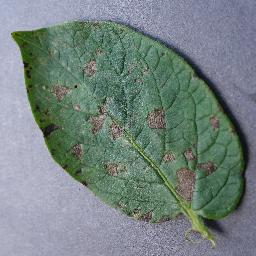


--- 0bbb8bce-2020-416b-8bd6-c160c2db9921___RS_Early.B 8386.JPG ---


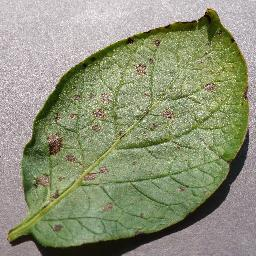


--- 0c4f6f72-c7a2-42e1-9671-41ab3bf37fe7___RS_Early.B 6752.JPG ---


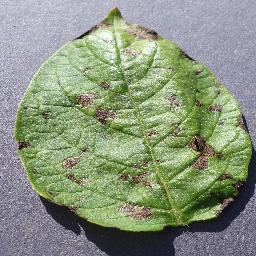


--- 0c5b14d9-8b1c-4c39-bb23-1835b5760caa___RS_Early.B 7937.JPG ---


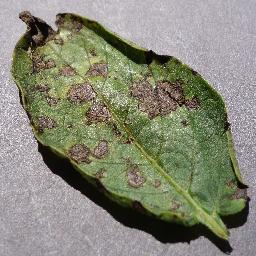


--- 0d2e2971-f1c9-4278-b35c-91dd8a22a64d___RS_Early.B 7581.JPG ---


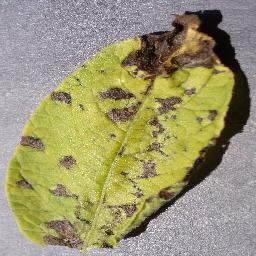


--- RS_Rust 1565.JPG ---


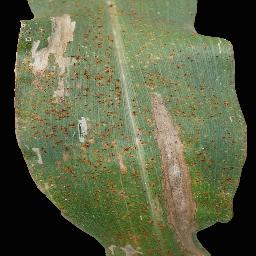


--- RS_Rust 1566.JPG ---


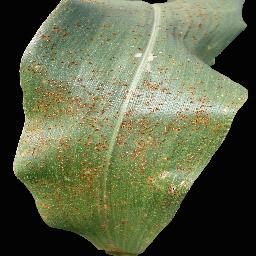


--- RS_Rust 1568_flipLR.JPG ---


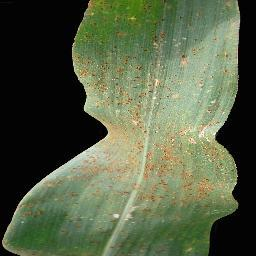


--- RS_Rust 1569.JPG ---


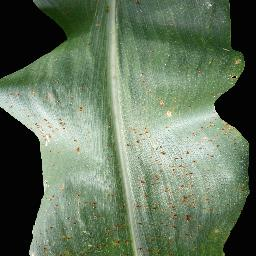

In [5]:
from IPython.display import Image, display

for f in image_files:
    print(f'--- {f.name} ---')
    display(Image(filename=str(f), width=350))
    print()

In [6]:
from pathlib import Path
import re

data_dir = Path(r'C:\Users\USER\rag_course\14_multimodal_rag\data')

image_files = sorted([
    f for f in data_dir.iterdir()
    if f.suffix.lower() in {'.jpg', '.jpeg', '.png'}
])

# Extract label from filename
def extract_label(filename: str) -> str:
    """Extract disease label from PlantVillage filename."""
    name = filename.lower()
    if 'early' in name:
        return 'early_blight'
    elif 'rust' in name:
        return 'rust'
    elif 'late' in name:
        return 'late_blight'
    elif 'healthy' in name:
        return 'healthy'
    return 'unknown'

print('Labels found:')
for f in image_files:
    label = extract_label(f.name)
    print(f'   {label:<15} ← {f.name}')

Labels found:
   early_blight    ← 0a79700b-f834-41f5-ae51-6ceda6f67a48___RS_Early.B 8951.JPG
   early_blight    ← 0ad3ba53-f01b-403b-a99d-5991eed85045___RS_Early.B 7600.JPG
   early_blight    ← 0bbb8bce-2020-416b-8bd6-c160c2db9921___RS_Early.B 8386.JPG
   early_blight    ← 0c4f6f72-c7a2-42e1-9671-41ab3bf37fe7___RS_Early.B 6752.JPG
   early_blight    ← 0c5b14d9-8b1c-4c39-bb23-1835b5760caa___RS_Early.B 7937.JPG
   early_blight    ← 0d2e2971-f1c9-4278-b35c-91dd8a22a64d___RS_Early.B 7581.JPG
   rust            ← RS_Rust 1565.JPG
   rust            ← RS_Rust 1566.JPG
   rust            ← RS_Rust 1568_flipLR.JPG
   rust            ← RS_Rust 1569.JPG


--- early_blight | 0a79700b-f834-41f5-ae51-6ceda6f67a48___RS_Early.B 8951.JPG ---


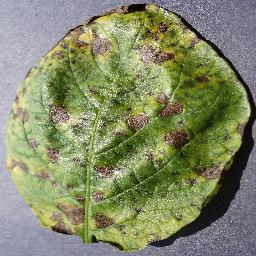


--- early_blight | 0ad3ba53-f01b-403b-a99d-5991eed85045___RS_Early.B 7600.JPG ---


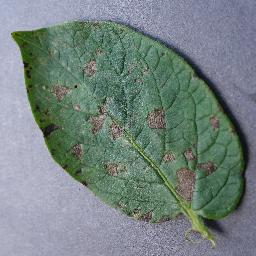


--- early_blight | 0bbb8bce-2020-416b-8bd6-c160c2db9921___RS_Early.B 8386.JPG ---


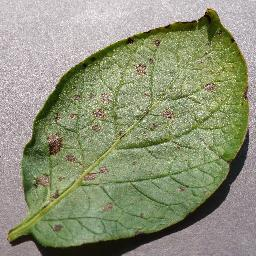


--- early_blight | 0c4f6f72-c7a2-42e1-9671-41ab3bf37fe7___RS_Early.B 6752.JPG ---


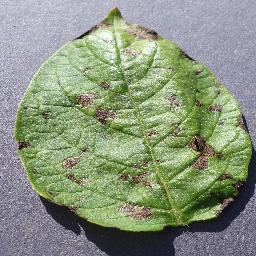


--- early_blight | 0c5b14d9-8b1c-4c39-bb23-1835b5760caa___RS_Early.B 7937.JPG ---


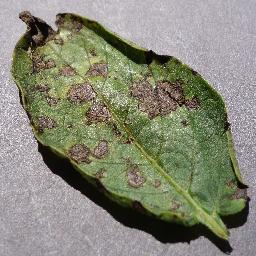


--- early_blight | 0d2e2971-f1c9-4278-b35c-91dd8a22a64d___RS_Early.B 7581.JPG ---


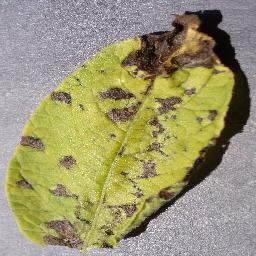


--- rust | RS_Rust 1565.JPG ---


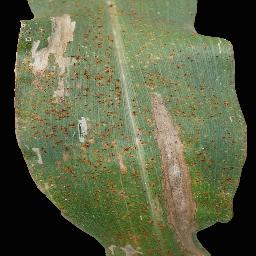


--- rust | RS_Rust 1566.JPG ---


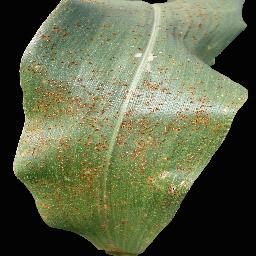


--- rust | RS_Rust 1568_flipLR.JPG ---


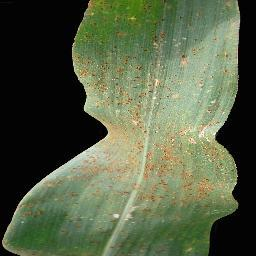


--- rust | RS_Rust 1569.JPG ---


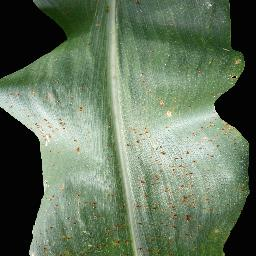

In [7]:
from IPython.display import Image, display

for f in image_files:
    label = extract_label(f.name)
    print(f'--- {label} | {f.name} ---')
    display(Image(filename=str(f), width=250))
    print()

GPT-4o Vision Test on One Image

In [8]:
data_dir = Path(r'C:\Users\USER\rag_course\14_multimodal_rag\data')

# Pick one image — the first early_blight
test_image = data_dir / '0a79700b-f834-41f5-ae51-6ceda6f67a48___RS_Early.B 8951.JPG'

# Read and encode the image as base64
with open(test_image, 'rb') as f:
    image_b64 = base64.b64encode(f.read()).decode('utf-8')
    
# Send to GPT-4o Vision
response = client.chat.completions.create(
    model='gpt-4o-mini',
    messages=[
        {
            'role': 'user',
            'content': [
                {
                    'type': 'text',
                    'text': 'What disease does this plant have? Answer with the disease name only.'
                },
                {
                    'type': 'image_url',
                    'image_url': {
                        'url': f'data:image/jpeg:base64,{image_b64}'
                    }
                },
            ],
        }
    ],
)
print(f'Image: {test_image.name}')
print(f'Ground truth: early_blight')
print(f'GPT-4o predicted: {response.choices[0].message.content}')

Image: 0a79700b-f834-41f5-ae51-6ceda6f67a48___RS_Early.B 8951.JPG
Ground truth: early_blight
GPT-4o predicted: Leaf Spot Disease


In [9]:
import base64
from pathlib import Path

data_dir = Path(r'C:\Users\USER\rag_course\14_multimodal_rag\data')

# Allowed classes — must match your ground truth labels
ALLOWED_CLASSES = ['early_blight', 'rust', 'healthy', 'unknown']

# System prompt constrains the model to pick from our list
system_prompt = (
    f'You are a potato disease classifier. '
    f'Given a leaf image, classify it as exactly one of: {", ".join(ALLOWED_CLASSES)}. '
    f'Answer with only the class name.'
)

# Extract label from filename (same logic as before)
def extract_label(filename: str) -> str:
    name = filename.lower()
    if 'early' in name:
        return 'early_blight'
    if 'rust' in name:
        return 'rust'
    if 'healthy' in name:
        return 'healthy'
    return 'unknown'

# Process all images
image_files = sorted([
    f for f in data_dir.iterdir()
    if f.suffix.lower() in {'.jpg', '.jpeg', '.png'}
])

results = []
for img_path in image_files:
    with open(img_path, 'rb') as f:
        b64 = base64.b64encode(f.read()).decode('utf-8')

    response = client.chat.completions.create(
        model='gpt-4o-mini',
        messages=[
            {'role': 'system', 'content': system_prompt},
            {'role': 'user', 'content': [
                {'type': 'image_url', 'image_url': {'url': f'data:image/jpeg;base64,{b64}'}},
            ]},
        ],
    )

    predicted = response.choices[0].message.content.strip().lower()
    truth = extract_label(img_path.name)
    correct = truth in predicted or predicted in truth

    results.append({'file': img_path.name, 'truth': truth, 'predicted': predicted, 'correct': correct})
    marker = '✅' if correct else '❌'
    print(f'{marker} truth={truth:<14} predicted={predicted:<20} {img_path.name[:40]}')

# Accuracy
correct_count = sum(r['correct'] for r in results)
accuracy = correct_count / len(results)
print(f'\n📊 Accuracy: {correct_count}/{len(results)} = {accuracy:.1%}')

✅ truth=early_blight   predicted=early_blight         0a79700b-f834-41f5-ae51-6ceda6f67a48___R
✅ truth=early_blight   predicted=early_blight         0ad3ba53-f01b-403b-a99d-5991eed85045___R
✅ truth=early_blight   predicted=early_blight         0bbb8bce-2020-416b-8bd6-c160c2db9921___R
✅ truth=early_blight   predicted=early_blight         0c4f6f72-c7a2-42e1-9671-41ab3bf37fe7___R
✅ truth=early_blight   predicted=early_blight         0c5b14d9-8b1c-4c39-bb23-1835b5760caa___R
✅ truth=early_blight   predicted=early_blight         0d2e2971-f1c9-4278-b35c-91dd8a22a64d___R
✅ truth=rust           predicted=rust                 RS_Rust 1565.JPG
✅ truth=rust           predicted=rust                 RS_Rust 1566.JPG
✅ truth=rust           predicted=rust                 RS_Rust 1568_flipLR.JPG
✅ truth=rust           predicted=rust                 RS_Rust 1569.JPG

📊 Accuracy: 10/10 = 100.0%


In [10]:
load_dotenv()

client = OpenAI()
rag_llm = ChatOpenAI(model='gpt-4o-mini', temperature=0)
embeddings = OpenAIEmbeddings()

persist_dir = r'C:\Users\USER\rag_course\chroma_db_domain'

vectorstore = Chroma(
    persist_directory=persist_dir, 
    embedding_function=embeddings
)

retriever = vectorstore.as_retriever(search_kwargs={'k': 4})

print(f'Vector store loaded — {vectorstore._collection.count()} chunks')

Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Vector store loaded — 80 chunks


The Full Multimodal RAG Function

In [11]:
def multimodal_rag(image_path: str) -> dict:
    """Image → disease → treatment, end to end.

    Returns dict with 'disease', 'answer', and 'context_used'.
    """
    # --- Step 1: Classify the image ---
    with open(image_path, 'rb') as f:
        b64 = base64.b64encode(f.read()).decode('utf-8')

    vision_response = client.chat.completions.create(
        model='gpt-4o-mini',
        messages=[
            {'role': 'system', 'content': (
                f'You are a plant disease classifier. '
                f'Classify the leaf image as exactly one of: {", ".join(ALLOWED_CLASSES)}. '
                f'Answer with only the class name.'
            )},
            {'role': 'user', 'content': [
                {'type': 'image_url', 'image_url': {'url': f'data:image/jpeg;base64,{b64}'}},
            ]},
        ],
    )
    disease = vision_response.choices[0].message.content.strip().lower()
    print(f'🔬 Classified: {disease}')

    # --- Step 2: Retrieve treatment docs ---
    docs = retriever.invoke(f'{disease} treatment')
    context = '\n\n'.join(d.page_content for d in docs)
    print(f'📚 Retrieved {len(docs)} docs')

    # --- Step 3: Generate the answer ---
    answer_prompt = ChatPromptTemplate.from_messages([
        ('system', 'Answer using ONLY the context below. If the context has no info about this disease, say "I don\'t have information about this disease in my knowledge base".'),
        ('human', 'Disease: {disease}\n\nContext:\n{context}'),
    ])

    answer_chain = answer_prompt | rag_llm | StrOutputParser()
    answer = answer_chain.invoke({'disease': disease, 'context': context})

    return {'disease': disease, 'answer': answer, 'context_used': context[:200]}


print('✅ multimodal_rag ready')

✅ multimodal_rag ready


Run the Full Pipeline

In [12]:
# Pick one image
test_img = data_dir / 'RS_Rust 1565.JPG'

result = multimodal_rag(str(test_img))

print(f'\n🎯 Disease: {result["disease"]}')
print(f'\n💬 Answer:\n{result["answer"]}')

🔬 Classified: rust


Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given


📚 Retrieved 4 docs

🎯 Disease: rust

💬 Answer:
I don't have information about this disease in my knowledge base.


Add Potato Disease Documents

In [13]:
from langchain_core.documents import Document

# 4 potato disease docs (ground truth treatment info)
potato_docs = [
    Document(
        page_content=(
            'Potato Early Blight is a fungal disease caused by Alternaria solani. '
            'Symptoms include dark brown spots with concentric rings on lower leaves, '
            'yellowing, and defoliation. Control: use resistant varieties, apply fungicides '
            'like chlorothalonil or mancozeb, practice crop rotation, and remove infected debris.'
        ),
        metadata={'domain': 'crops', 'crop': 'potato', 'disease': 'early_blight'},
    ),
    Document(
        page_content=(
            'Potato Late Blight is a devastating disease caused by Phytophthora infestans. '
            'Symptoms include water-soaked lesions, white fungal growth on leaf undersides, '
            'and rapid plant collapse. Control: plant resistant varieties, apply fungicides '
            'preventively, ensure good drainage, and destroy infected plants immediately.'
        ),
        metadata={'domain': 'crops', 'crop': 'potato', 'disease': 'late_blight'},
    ),
    Document(
        page_content=(
            'Potato Rust is a fungal disease caused by Puccinia pittieriana. '
            'Symptoms include orange to brown pustules on leaves and stems. '
            'Control: use resistant varieties, apply fungicides containing sulfur or copper, '
            'practice crop rotation, and remove infected plants.'
        ),
        metadata={'domain': 'crops', 'crop': 'potato', 'disease': 'rust'},
    ),
    Document(
        page_content=(
            'Healthy potato plants have uniform green leaves with no spots, lesions, '
            'or discolouration. Maintain plant health through balanced fertilization, '
            'proper spacing for air circulation, and regular monitoring for early signs of disease.'
        ),
        metadata={'domain': 'crops', 'crop': 'potato', 'disease': 'healthy'},
    ),
]

print(f'{len(potato_docs)} potato docs ready')

4 potato docs ready


Build the Retriever

In [14]:
# Build a fresh in-memory store with potato docs
potato_store = Chroma.from_documents(
    documents=potato_docs,
    embedding=embeddings,
    collection_name='potato_demo',
)

potato_retriever = potato_store.as_retriever(search_kwargs={'k': 3})

print(f'Potato retriever ready — {potato_store._collection.count()} docs')

Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Potato retriever ready — 4 docs


Test the Full Pipeline with Potato Docs

In [15]:
def multimodal_rag_v2(image_path: str) -> dict:
    """Image → disease → retrieve potato treatment → answer."""

    # Step 1: Classify
    with open(image_path, 'rb') as f:
        b64 = base64.b64encode(f.read()).decode('utf-8')

    vision_response = client.chat.completions.create(
        model='gpt-4o-mini',
        messages=[
            {'role': 'system', 'content': (
                f'You are a potato disease classifier. '
                f'Classify the leaf image as exactly one of: {", ".join(ALLOWED_CLASSES)}. '
                f'Answer with only the class name.'
            )},
            {'role': 'user', 'content': [
                {'type': 'image_url', 'image_url': {'url': f'data:image/jpeg;base64,{b64}'}},
            ]},
        ],
    )
    disease = vision_response.choices[0].message.content.strip().lower()
    print(f'Classified: {disease}')

    # Step 2: Retrieve using the potato retriever
    docs = potato_retriever.invoke(f'potato {disease} treatment')
    context = '\n\n'.join(d.page_content for d in docs)
    print(f'Retrieved {len(docs)} docs')

    # Step 3: Generate answer
    answer_prompt = ChatPromptTemplate.from_messages([
        ('system', 'Answer using ONLY the context below. If the context has no info, say "I don\'t know".'),
        ('human', 'Disease: {disease}\n\nContext:\n{context}'),
    ])
    answer_chain = answer_prompt | rag_llm | StrOutputParser()
    answer = answer_chain.invoke({'disease': disease, 'context': context})

    return {'disease': disease, 'answer': answer}


# Test with a rust image
result = multimodal_rag_v2(str(data_dir / 'RS_Rust 1565.JPG'))
print(f'\nDisease: {result["disease"]}')
print(f'\nAnswer:\n{result["answer"]}')

Classified: rust


Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given


Retrieved 3 docs

Disease: rust

Answer:
I don't know.


In [16]:
result = multimodal_rag_v2(str(data_dir / '0a79700b-f834-41f5-ae51-6ceda6f67a48___RS_Early.B 8951.JPG'))
print(f'\nDisease: {result["disease"]}')
print(f'\nAnswer:\n{result["answer"]}')

Classified: early_blight
Retrieved 3 docs

Disease: early_blight

Answer:
Early Blight is a fungal disease caused by Alternaria solani. Symptoms include dark brown spots with concentric rings on lower leaves, yellowing, and defoliation. Control methods include using resistant varieties, applying fungicides like chlorothalonil or mancozeb, practicing crop rotation, and removing infected debris.
